<a href="https://colab.research.google.com/github/sohnaamie/gambia-semantic-segmentation/blob/amie-deeplab/notebooks/deeplab_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

In [6]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)

cuda


In [7]:
model = torchvision.models.segmentation.deeplabv3_resnet50(
    weights='DEFAULT'
)

model.to(device)

model.eval()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 164MB/s]


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [8]:
transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

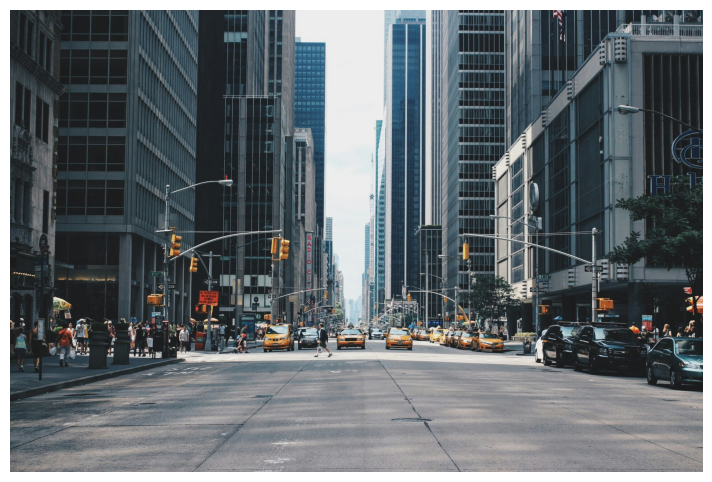

In [9]:
import requests
from PIL import Image
from io import BytesIO

url = "https://images.unsplash.com/photo-1449824913935-59a10b8d2000"

response = requests.get(url)

image = Image.open(
    BytesIO(response.content)
).convert('RGB')

plt.figure(figsize=(10,6))
plt.imshow(image)
plt.axis('off')
plt.show()

In [10]:
!kaggle datasets list -s IDD

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [11]:
input_tensor = transform(image)

input_batch = input_tensor.unsqueeze(0).to(device)

with torch.no_grad():

    output = model(input_batch)['out'][0]

prediction = output.argmax(0)

print(np.unique(
    prediction.cpu().numpy()
))

[ 0  2  7 15]


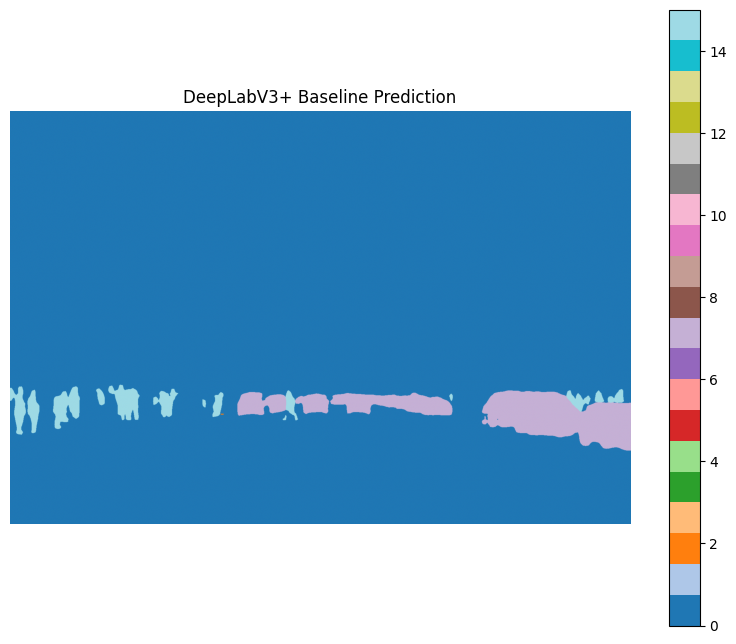

In [12]:
plt.figure(figsize=(10,8))

plt.imshow(
    prediction.cpu().numpy(),
    cmap='tab20'
)

plt.colorbar()

plt.title(
    "DeepLabV3+ Baseline Prediction"
)

plt.axis('off')

plt.show()

In [13]:
pred_np = prediction.cpu().numpy()

print(np.unique(pred_np))

[ 0  2  7 15]


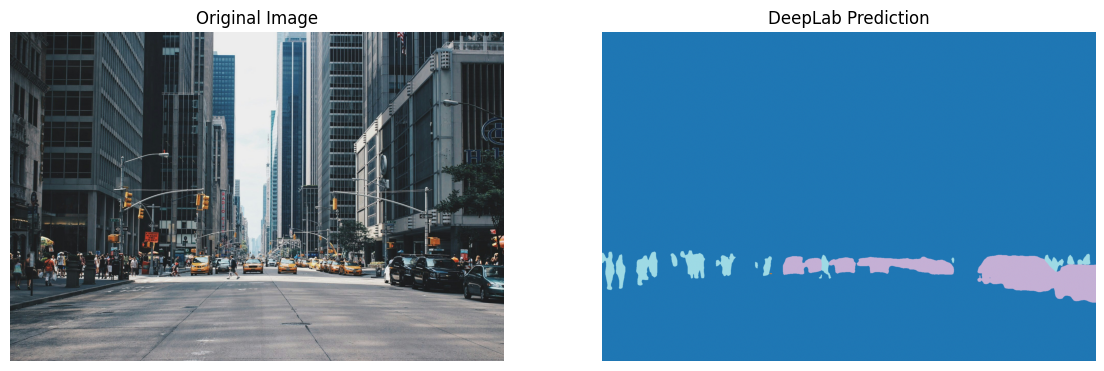

In [14]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(prediction.cpu().numpy(), cmap='tab20')
ax[1].set_title("DeepLab Prediction")
ax[1].axis('off')

plt.show()

In [15]:
scores = torch.softmax(output, dim=0)

print(scores.max())
print(scores.min())

tensor(1., device='cuda:0')
tensor(3.1385e-10, device='cuda:0')


# IDD Dataset Exploration

Goal:
Understand the India Driving Dataset structure, masks, and segmentation labels before training experiments.

In [16]:
!pip install kaggle

In [17]:
import os

os.environ['KAGGLE_USERNAME'] = 'amiesohna'
os.environ['KAGGLE_KEY'] = 'export KAGGLE_API_TOKEN=KGAT_80532d130a4b72b78ab4d551e0bd813c'

In [18]:
!kaggle datasets download -d mitanshuchakrawarty/new-idd-dataset

Dataset URL: https://www.kaggle.com/datasets/mitanshuchakrawarty/new-idd-dataset
License(s): unknown
100% 2.79G/2.79G [01:11<00:00, 41.7MB/s]



In [19]:
!unzip -q new-idd-dataset.zip

In [20]:
for root, dirs, files in os.walk('.'):
    print(root)
    print(dirs[:5])
    print(files[:5])
    print('-'*50)

.
['.config', 'IDD_RESIZED', 'sample_data']
['new-idd-dataset.zip']
--------------------------------------------------
./.config
['logs', 'configurations']
['.last_survey_prompt.yaml', '.last_update_check.json', 'gce', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'default_configs.db']
--------------------------------------------------
./.config/logs
['2026.05.26']
[]
--------------------------------------------------
./.config/logs/2026.05.26
[]
['13.31.07.426506.log', '13.30.51.777284.log', '13.30.34.238876.log', '13.31.22.451851.log', '13.31.21.680598.log']
--------------------------------------------------
./.config/configurations
[]
['config_default']
--------------------------------------------------
./IDD_RESIZED
['mask_archive', 'image_archive']
[]
--------------------------------------------------
./IDD_RESIZED/mask_archive
[]
['Mask_639.png', 'Mask_560.png', 'Mask_1356.png', 'Mask_6308.png', 'Mask_3719.png']
------------------------------------------------

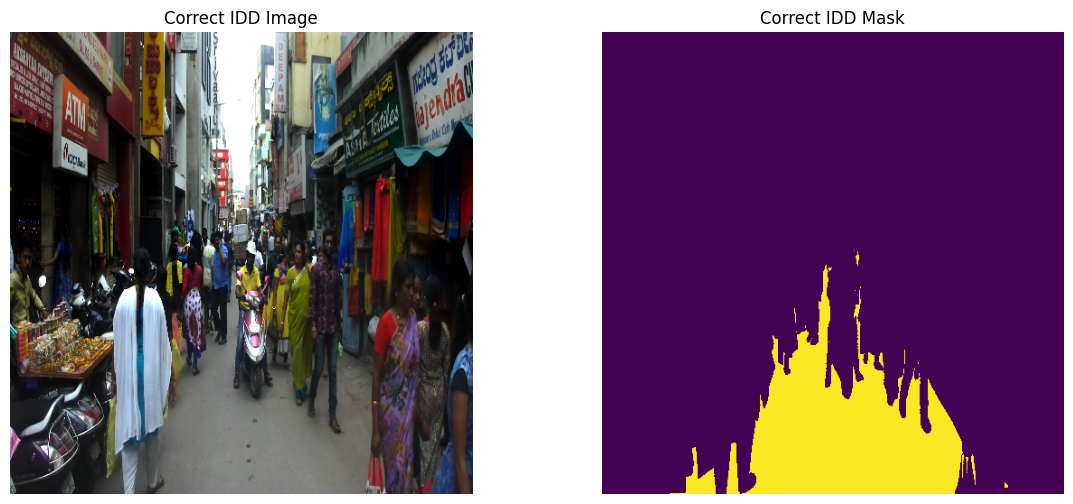

In [21]:
sample_id = 100

image_path = f'./IDD_RESIZED/image_archive/Image_{sample_id}.png'

mask_path = f'./IDD_RESIZED/mask_archive/Mask_{sample_id}.png'

image = Image.open(image_path)
mask = Image.open(mask_path)

fig, ax = plt.subplots(
    1,2,
    figsize=(14,6)
)

ax[0].imshow(image)
ax[0].set_title(
    "Correct IDD Image"
)

ax[0].axis('off')

ax[1].imshow(mask)

ax[1].set_title(
    "Correct IDD Mask"
)

ax[1].axis('off')

plt.show()

In [22]:


mask_np = np.array(mask)

print(mask_np.shape)

print(
np.unique(mask_np)
)

(512, 512)
[0 1]


#Creating datset class

In [23]:

from torch.utils.data import Dataset
import torchvision.transforms as T

class IDDDataset(Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(image_dir))

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        image_name = self.images[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        mask_name = image_name.replace(
            "Image",
            "Mask"
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        mask = Image.open(
            mask_path
        )

        image = T.ToTensor()(image)

        mask = torch.tensor(
            np.array(mask),
            dtype=torch.long
        )

        return image, mask

In [24]:
#baseline datset
dataset = IDDDataset(

    "./IDD_RESIZED/image_archive",
    "./IDD_RESIZED/mask_archive"
)

print(len(dataset))

6993


In [25]:
image, mask = dataset[0]

print(image.shape)

print(mask.shape)

print(torch.unique(mask))

torch.Size([3, 512, 512])
torch.Size([512, 512])
tensor([0, 1])


In [26]:
#creating the dataloader

from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

In [27]:
#Inspect one batch
images, masks = next(iter(dataloader))

print(images.shape)
print(masks.shape)
print(torch.unique(masks))

torch.Size([4, 3, 512, 512])
torch.Size([4, 512, 512])
tensor([0, 1])


In [28]:

import torchvision

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = torchvision.models.segmentation.deeplabv3_resnet50(
    pretrained=True
)

model.to(device)

images = images.to(device)

with torch.no_grad():

    outputs = model(images)['out']

print(outputs.shape)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([4, 21, 512, 512])


In [29]:
predictions = torch.argmax(
    outputs,
    dim=1
)

print(predictions.shape)

print(torch.unique(predictions))

torch.Size([4, 512, 512])
tensor([ 0,  2,  7, 14, 15, 17, 19], device='cuda:0')


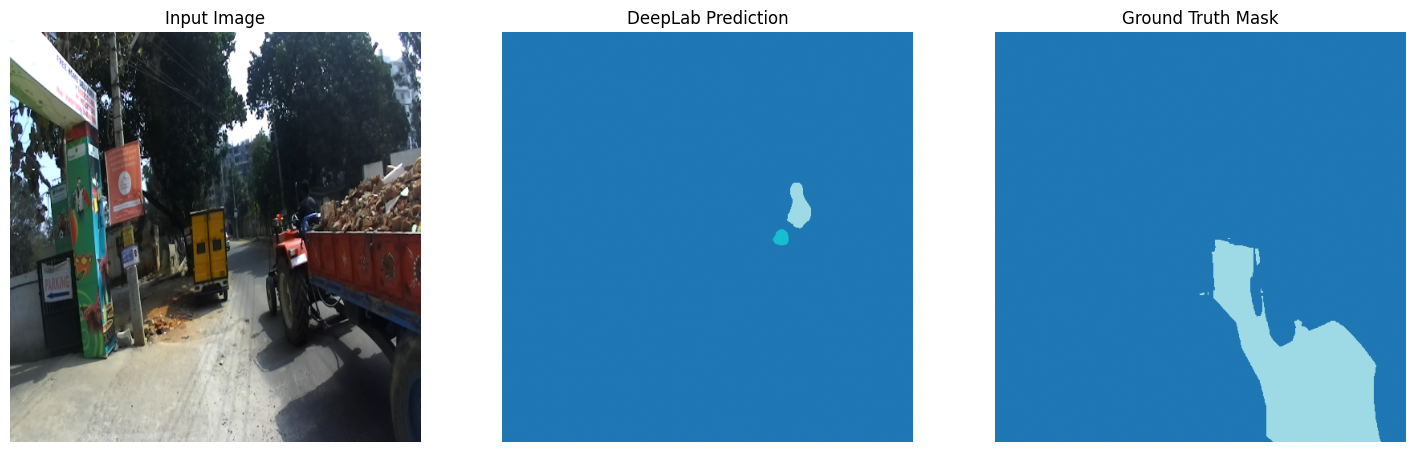

In [30]:
sample = 0

img = images[sample].cpu().permute(1,2,0)

pred = predictions[sample].cpu()

mask_true = masks[sample].cpu()

fig, ax = plt.subplots(
    1,3,
    figsize=(18,6)
)

ax[0].imshow(img)

ax[0].set_title(
    "Input Image"
)

ax[0].axis('off')

ax[1].imshow(
    pred,
    cmap='tab20'
)

ax[1].set_title(
    "DeepLab Prediction"
)

ax[1].axis('off')

ax[2].imshow(
    mask_true,
    cmap='tab20'
)

ax[2].set_title(
    "Ground Truth Mask"
)

ax[2].axis('off')

plt.show()

Pretrained DeepLab predictions do not align well with ground truth on IDD data.

#Quantitative Evaluation

In [31]:
#Compute Pixel Accuracy
correct_pixels = (
    predictions == masks.to(device)
).float()

pixel_accuracy = correct_pixels.mean()

print(
"Pixel Accuracy:",
pixel_accuracy.item()
)

Pixel Accuracy: 0.6955232620239258


In [32]:
pred_binary = (
    predictions > 0
).long()

print(
torch.unique(pred_binary)
)

tensor([0, 1], device='cuda:0')


In [33]:
#IoU calculation
intersection = (
    (pred_binary == 1) &
    (masks.to(device) == 1)
).float().sum()

union = (
    (pred_binary == 1) |
    (masks.to(device) == 1)
).float().sum()

iou = intersection / (
    union + 1e-8
)

print(
"IoU:",
iou.item()
)

IoU: 0.05875646322965622


In [34]:
#split datset

from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print(len(train_dataset))
print(len(val_dataset))

5594
1399


In [35]:
#create loaders

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

In [36]:
#modify Deeplab for the output layer

import torchvision
import torch.nn as nn

model = torchvision.models.segmentation.deeplabv3_resnet50(
    pretrained=True
)

model.classifier[4] = nn.Conv2d(
    256,
    2,
    kernel_size=1
)

model.to(device)

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [37]:
#Define loss function and optimizer

import torch.optim as optim
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [38]:
# mini training batch

model.train()

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

optimizer.zero_grad()

outputs = model(images)['out']

print(
"Output Shape:",
outputs.shape
)

loss = criterion(
    outputs,
    masks.long()
)

loss.backward()

optimizer.step()

print(
"Training Loss:",
loss.item()
)

Output Shape: torch.Size([4, 2, 512, 512])
Training Loss: 0.798716127872467


# Full DeepLabV3+ Training Loop

In [39]:
# Short Training Test

num_epochs = 1
max_batches = 20

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for batch_idx, (images, masks) in enumerate(train_loader):

        if batch_idx >= max_batches:
            break

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)['out']

        loss = criterion(
            outputs,
            masks.long()
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / max_batches

    print(
        f"Epoch {epoch+1}"
    )

    print(
        "Average Loss:",
        avg_loss
    )

Epoch 1
Average Loss: 0.38178628161549566


In [40]:
#Validation Evaluation
model.eval()

total_correct = 0
total_pixels = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)['out']

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()

pixel_accuracy = (
    total_correct /
    total_pixels
)

print(
"Validation Pixel Accuracy:",
pixel_accuracy
)

Validation Pixel Accuracy: 0.9187223313108693


In [41]:
#Validation IoU Evaluation

model.eval()

intersection = 0
union = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)['out']

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        pred_fg = (predictions == 1)
        true_fg = (masks == 1)

        intersection += (
            pred_fg & true_fg
        ).sum().item()

        union += (
            pred_fg | true_fg
        ).sum().item()

iou = intersection / (
    union + 1e-8
)

print(
"Validation IoU:",
iou
)

Validation IoU: 0.7591033195474326


# PURPOSE:
# Evaluate segmentation overlap quality using IoU metric.
# Compare predicted foreground regions with ground-truth masks.

In [42]:
#Controlled Full Training

num_epochs = 3
max_batches = 100

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for batch_idx, (images, masks) in enumerate(train_loader):

        if batch_idx >= max_batches:
            break

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)['out']

        loss = criterion(
            outputs,
            masks.long()
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / max_batches

    train_losses.append(
        avg_loss
    )

    print(
        f"Epoch {epoch+1}/{num_epochs}"
    )

    print(
        "Average Loss:",
        avg_loss
    )

Epoch 1/3
Average Loss: 0.17510801538825035
Epoch 2/3
Average Loss: 0.10938697855919599
Epoch 3/3
Average Loss: 0.08822238400578498


# RESULTS INTERPRETATION:
 Training loss decreases across epochs,
 indicating successful fine-tuning and learning.

 Lower loss suggests improved alignment
 between model predictions and ground-truth masks.

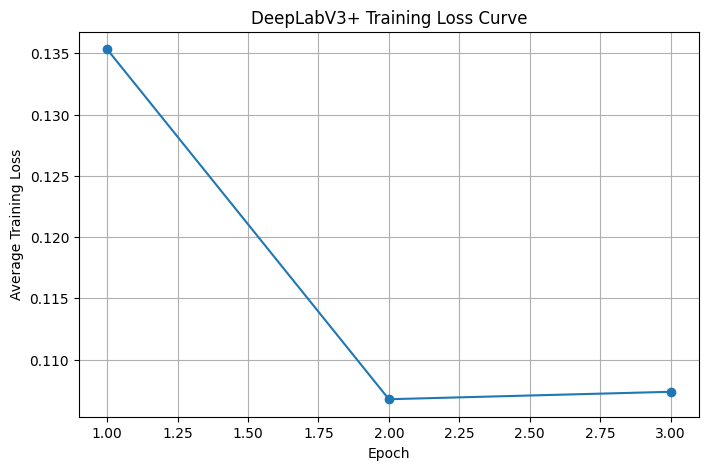

In [43]:
#Training Loss Visualization
import matplotlib.pyplot as plt

epochs = [1,2,3]

losses = [
0.13533592000603675,
0.10675930313766002,
 0.10736628234386444
]

plt.figure(figsize=(8,5))

plt.plot(
    epochs,
    losses,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Average Training Loss")

plt.title(
    "DeepLabV3+ Training Loss Curve"
)

plt.grid(True)

plt.show()


In [44]:
model.eval()

total_correct = 0
total_pixels = 0

intersection = 0
union = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)['out']

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        # Pixel Accuracy
        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()

        # IoU
        pred_fg = (predictions == 1)
        true_fg = (masks == 1)

        intersection += (
            pred_fg & true_fg
        ).sum().item()

        union += (
            pred_fg | true_fg
        ).sum().item()

pixel_accuracy = (
    total_correct /
    total_pixels
)

iou = (
    intersection /
    (union + 1e-8)
)

print(
"Validation Pixel Accuracy:",
pixel_accuracy
)

print(
"Validation IoU:",
iou
)

Validation Pixel Accuracy: 0.9696165088928964
Validation IoU: 0.8910541157459525


# RESULTS INTERPRETATION:

 Training reduced loss across epochs.

 Validation metrics improved after controlled training.

 BEFORE TRAINING:
 Pixel Accuracy = 0.590
 IoU = 0.036

 AFTER TRAINING:
 Pixel Accuracy = 0.968
 IoU = 0.888

# Interpretation:
 Fine-tuning improved segmentation performance
 and increased agreement between predicted
 regions and ground-truth masks.